<a href="https://colab.research.google.com/github/GeorgeT27/Generative-model-DYI/blob/main/Conditional_Flow_Matching_Morpho_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import math
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import StepLR
import torch.distributions as distributions
from tqdm import tqdm
import pandas as pd

from copy import deepcopy
import os
import sys
sys.path.append('/content/drive/MyDrive/MorphoMnist/Morpho-MNIST')
from morphomnist import io

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
class RectifiedFlow:
  def euler(self,x_t,v,dt):
    x_t=x_t+v*dt
    return x_t
  def create_flow(self,x_1,t):
    x_0=torch.randn_like(x_1)
    t=t[:,None,None,None]
    x_t=t*x_1+(1-t)*x_0
    return x_t,x_0
  def mse_loss(self,x_1,x_0,v):
    loss=F.mse_loss(x_1-x_0,v)
    return loss

In [6]:
# MiniUnet MNIST 28*28 4090 3G左右显存
class DownLayer(nn.Module):
    """MiniUnet的下采样层 Resnet
    """

    def __init__(self,
                 in_channels,
                 out_channels,
                 time_emb_dim=16,
                 downsample=False):
        super(DownLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道 [B, dim] -> [B, in_channels]
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

        # 降采样
        self.downsample = downsample
        if downsample:
            self.pool = nn.MaxPool2d(2)

        self.in_channels = in_channels

    def forward(self, x, temb):
        # x: [B, C, H, W]
        res = x
        x += self.fc(temb)[:, :, None, None]  # [B, in_channels, 1, 1]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            res = self.shortcut(res)

        x = x + res

        if self.downsample:
            x = self.pool(x)

        return x


class UpLayer(nn.Module):
    """MiniUnet的上采样层
    """

    def __init__(self,
                 in_channels,
                 out_channels,
                 time_emb_dim=16,
                 upsample=False):
        super(UpLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

        self.upsample = upsample
        if upsample:
            self.upsample = nn.Upsample(scale_factor=2)

    def forward(self, x, temb):
        # 上采样
        if self.upsample:
            x = self.upsample(x)
        res = x

        x += self.fc(temb)[:, :, None, None]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            res = self.shortcut(res)
        x = x + res

        return x


class MiddleLayer(nn.Module):
    """MiniUnet的中间层
    """

    def __init__(self, in_channels, out_channels, time_emb_dim=16):
        super(MiddleLayer, self).__init__()

        self.conv1 = nn.Conv2d(in_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.conv2 = nn.Conv2d(out_channels,
                               out_channels,
                               kernel_size=3,
                               padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.act = nn.ReLU()

        # 线性层，用于时间编码换通道
        self.fc = nn.Linear(time_emb_dim, in_channels)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.shortcut = None

    def forward(self, x, temb):
        res = x

        x += self.fc(temb)[:, :, None, None]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act(x)

        if self.shortcut is not None:
            x = self.shortcut(x)
        x = x + res

        return x


class MiniUnet(nn.Module):
    """采用MiniUnet，对MNIST数据做生成
        两个下采样block 一个中间block 两个上采样block
    """

    def __init__(self, base_channels=16, time_emb_dim=None, use_morphometrics=False):
        super(MiniUnet, self).__init__()

        if time_emb_dim is None:
            self.time_emb_dim = base_channels

        self.base_channels = base_channels
        self.use_morphometrics = use_morphometrics

        self.conv_in = nn.Conv2d(1, base_channels, kernel_size=3, padding=1)

        # Add morphometric embedding layers
        if use_morphometrics:
            # Linear layers to project morphometric features to embedding space
            self.area_proj = nn.Linear(1, self.base_channels)
            self.thickness_proj = nn.Linear(1, self.base_channels)
            self.length_proj = nn.Linear(1, self.base_channels)

        # 多个Layer构成block
        self.down1 = nn.ModuleList([
            DownLayer(base_channels,
                      base_channels * 2,
                      time_emb_dim=self.time_emb_dim,
                      downsample=False),
            DownLayer(base_channels * 2,
                      base_channels * 2,
                      time_emb_dim=self.time_emb_dim)
        ])
        self.maxpool1 = nn.MaxPool2d(2)

        self.down2 = nn.ModuleList([
            DownLayer(base_channels * 2,
                      base_channels * 4,
                      time_emb_dim=self.time_emb_dim,
                      downsample=False),
            DownLayer(base_channels * 4,
                      base_channels * 4,
                      time_emb_dim=self.time_emb_dim)
        ])
        self.maxpool2 = nn.MaxPool2d(2)

        self.middle = MiddleLayer(base_channels * 4,
                                  base_channels * 4,
                                  time_emb_dim=self.time_emb_dim)

        self.upsample1 = nn.Upsample(scale_factor=2)
        self.up1 = nn.ModuleList([
            UpLayer(
                base_channels * 8,  # concat
                base_channels * 2,
                time_emb_dim=self.time_emb_dim,
                upsample=False),
            UpLayer(base_channels * 2,
                    base_channels * 2,
                    time_emb_dim=self.time_emb_dim)
        ])
        self.upsample2 = nn.Upsample(scale_factor=2)
        self.up2 = nn.ModuleList([
            UpLayer(base_channels * 4,
                    base_channels,
                    time_emb_dim=self.time_emb_dim,
                    upsample=False),
            UpLayer(base_channels,
                    base_channels,
                    time_emb_dim=self.time_emb_dim)
        ])

        self.conv_out = nn.Conv2d(base_channels, 1, kernel_size=1, padding=0)

    def time_emb(self, t, dim):
        """对时间进行正弦函数的编码，单一维度
       目标：让模型感知到输入x_t的时刻t
       实现方式：多种多样
       输入x：[B, C, H, W] x += temb 与空间无关的，也即每个空间位置（H, W）,都需要加上一个相同的时间编码向量[B, C]
       假设B=1 t=0.1
       1. 简单粗暴法
       temb = [0.1] * C -> [0.1, 0.1, 0.1, ……]
       x += temb.reshape(1, C, 1, 1)
       2. 类似绝对位置编码方式
       本代码实现方式
       3. 通过学习的方式（保证T是离散的0， 1， 2， 3，……，T）
       temb_learn = nn.Parameter(T+1, dim)
       x += temb_learn[t, :].reshape(1, C, 1, 1)


        Args:
            t (float): 时间，维度为[B]
            dim (int): 编码的维度

        Returns:
            torch.Tensor: 编码后的时间，维度为[B, dim]  输入是[B, C, H, W]
        """
        # 生成正弦编码
        # 把t映射到[0, 1000]
        t = t * 1000
        # 10000^k k=torch.linspace……
        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(t.device)
        sin_emb = torch.sin(t[:, None] / freqs)
        cos_emb = torch.cos(t[:, None] / freqs)

        return torch.cat([sin_emb, cos_emb], dim=-1)

    def label_emb(self, y, dim):
        """对类别标签进行编码，同样采用正弦编码

        Args:
            y (torch.Tensor): 图像标签，维度为[B] label:0-9
            dim (int): 编码的维度

        Returns:
            torch.Tensor: 编码后的标签，维度为[B, dim]
        """
        y = y * 1000

        freqs = torch.pow(10000, torch.linspace(0, 1, dim // 2)).to(y.device)
        sin_emb = torch.sin(y[:, None] / freqs)
        cos_emb = torch.cos(y[:, None] / freqs)

        return torch.cat([sin_emb, cos_emb], dim=-1)

    def morphometric_emb(self, morpho_dict):
        """Encode morphometric features

        Args:
            morpho_dict: Dictionary with keys 'area', 'thickness', 'length', etc.
                        Each value is a tensor of shape [B]
        Returns:
            torch.Tensor: Combined morphometric embedding [B, base_channels]
        """
        if not self.use_morphometrics or morpho_dict is None:
            return torch.zeros(morpho_dict['area'].size(0), self.base_channels,
                             device=morpho_dict['area'].device)

        # Normalize the features (important for training stability)
        area_norm = (morpho_dict['area'] - morpho_dict['area'].mean()) / (morpho_dict['area'].std() + 1e-8)
        thickness_norm = (morpho_dict['thickness'] - morpho_dict['thickness'].mean()) / (morpho_dict['thickness'].std() + 1e-8)
        length_norm = (morpho_dict['length'] - morpho_dict['length'].mean()) / (morpho_dict['length'].std() + 1e-8)

        # Project to embedding space
        area_emb = self.area_proj(area_norm.unsqueeze(-1))  # [B, 1] -> [B, base_channels]
        thickness_emb = self.thickness_proj(thickness_norm.unsqueeze(-1))
        length_emb = self.length_proj(length_norm.unsqueeze(-1))

        # Combine embeddings
        morpho_emb = area_emb + thickness_emb + length_emb

        return morpho_emb

    def forward(self, x, t, y=None, morpho=None):
        """前向传播函数

        Args:
            x (torch.Tensor): 输入数据，维度为[B, C, H, W]
            t (torch.Tensor): 时间，维度为[B]
            y (torch.Tensor, optional): 数据标签（每一个标签是一个类别int型）或text文本（下一版本支持）,维度为[B]或[B, L]。 Defaults to None.
            morpho (dict, optional): 形态学特征字典，包含area, thickness, length等. Defaults to None.
        """
        # x:(B, C, H, W)
        # 时间编码加上
        x = self.conv_in(x)
        # 时间编码
        temb = self.time_emb(t, self.base_channels)
        # 这里注意，我们把temb和labelemb加起来，作为一个整体的temb输入到MiniUnet中，让模型进行感知！二者编码维度一样，可以直接相加！就把label的条件信息融入进去了！
        if y is not None:
            # 判断y是label还是token
            if len(y.shape) == 1:
                # label编码，-1表示无条件生成，仅用于训练区分，推理的时候不需要
                # 把y中等于-1的部分找出来不进行任何编码，其余的进行编码
                yemb = self.label_emb(y, self.base_channels)
                # 把y等于-1的index找出来，然后把对应的y_emb设置为0
                yemb[y == -1] = 0.0
                temb += yemb
            else:  # 文字版本
                pass

        # 形态学特征编码 (新增)
        if morpho is not None and self.use_morphometrics:
            morpho_emb = self.morphometric_emb(morpho)
            temb += morpho_emb
        # 下采样
        for layer in self.down1:
            x = layer(x, temb)
        x1 = x
        x = self.maxpool1(x)
        for layer in self.down2:
            x = layer(x, temb)
        x2 = x
        x = self.maxpool2(x)

        # 中间层
        x = self.middle(x, temb)

        # 上采样
        x = torch.cat([self.upsample1(x), x2], dim=1)
        for layer in self.up1:
            x = layer(x, temb)
        x = torch.cat([self.upsample2(x), x1], dim=1)
        for layer in self.up2:
            x = layer(x, temb)

        x = self.conv_out(x)
        return x


In [7]:
class EMA(nn.Module):
    def __init__(self, model, decay=0.9999, device=None):
        super(EMA, self).__init__()
        # make a copy of the model for accumulating moving average of weights
        self.module = deepcopy(model)
        self.module.eval()
        self.decay = decay
        self.device = device  # perform EMA on different device from model if set
        if self.device is not None:
            self.module.to(device=self.device)

    def _update(self, model, update_fn):
        with torch.no_grad():
            for ema_v, model_v in zip(self.module.state_dict().values(),
                                      model.state_dict().values()):
                if self.device is not None:
                    model_v = model_v.to(device=self.device)
                ema_v.copy_(update_fn(ema_v, model_v))

    def update(self, model):
        self._update(
            model,
            update_fn=lambda e, m: self.decay * e + (1.0 - self.decay) * m
        )

    def set(self, model):
        self._update(
            model,
            update_fn=lambda e, m: m
        )

In [8]:
# Improved training configuration
epochs= 100  # More epochs
batch_size= 128  # Larger batch size for more stable gradients
lr= 5e-4  # Slightly higher learning rate initially
weight_decay= 1e-4  # Less regularization
ema_decay= 0.9999
grad_clip= 1.0
lr_schedule= True
step_size= 40  # Reduce LR later
gamma= 0.5 # More gradual LR reduction
lr_adjust_epoch= 25 # 学习率调整的epoch，降为原有的10%
batch_print_interval= 100 # 打印间隔，以batch为单位
device= 'cuda' # cuda、cpu、mps(only macbook)
checkpoint_save_interval= 10 # 模型保存间隔，以epoch为单位

## Download Morpho-MNIST Dataset

Morpho-MNIST provides several dataset variants:

- **plain**: Plain digits only (16 MB)
- **global**: Plain + thinning + thickening (15 MB)  
- **local**: Plain + swelling + fractures (16 MB)
- **thin**: Thinning only (13 MB)
- **thic**: Thickening only (16 MB)
- **swel**: Swelling only (17 MB)
- **frac**: Fractures only (16 MB)

### Manual Download Required:
1. Go to: https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL
2. Download one of the datasets (e.g., "global" for diverse perturbations)
3. Extract to: `/Users/tqa946816/Generative-model-DYI/data/morpho-mnist/`

### Dataset Structure:
Each dataset contains:
- `[train|t10k]-images-idx3-ubyte.gz`: Images
- `[train|t10k]-labels-idx1-ubyte.gz`: Digit labels (0-9)
- `[train|t10k]-morpho.csv`: Morphometrics (area, length, thickness, slant, width, height)
- `[train|t10k]-pert-idx1-ubyte.gz`: Perturbation labels (0: plain, 1: thinned, 2: thickened, 3: swollen, 4: fractured)

In [10]:
class MorphoMNISTDataset(torch.utils.data.Dataset):
    """Custom dataset class for Morpho-MNIST data"""

    def __init__(self, root, train=True, download=False, transform=None,
                 load_morphometrics=False, load_perturbations=False):
        self.root = root
        self.train = train
        self.transform = transform
        self.load_morphometrics = load_morphometrics
        self.load_perturbations = load_perturbations

        # Create morpho-mnist directory
        self.morpho_dir = os.path.join(root, 'morpho-mnist')
        if not os.path.exists(self.morpho_dir):
            os.makedirs(self.morpho_dir)

        if download:
            self.download_data()

        # Load data
        self.data, self.targets, self.morphometrics, self.perturbations = self._load_data()

    def download_data(self):
        """Download Morpho-MNIST data if not exists"""
        print("Please download Morpho-MNIST data manually from:")
        print("https://drive.google.com/drive/folders/1ZzTBfXUKa4JW0lHkUIJ1qFCCSkOqWFvL")
        print("Choose one of: plain, global, local, thin, thic, swel, frac")
        print(f"Extract to: {self.morpho_dir}")

    def _load_data(self):
        """Load Morpho-MNIST data files"""
        prefix = 'train' if self.train else 't10k'

        # Load images
        images_file = os.path.join(self.morpho_dir, f'{prefix}-images-idx3-ubyte.gz')
        if not os.path.exists(images_file):
            # Try without .gz extension
            images_file = os.path.join(self.morpho_dir, f'{prefix}-images-idx3-ubyte')

        if os.path.exists(images_file):
            images = io.load_idx(images_file)
        else:
            raise FileNotFoundError(f"Images file not found: {images_file}")

        # Load labels
        labels_file = os.path.join(self.morpho_dir, f'{prefix}-labels-idx1-ubyte.gz')
        if not os.path.exists(labels_file):
            labels_file = os.path.join(self.morpho_dir, f'{prefix}-labels-idx1-ubyte')

        if os.path.exists(labels_file):
            labels = io.load_idx(labels_file)
        else:
            raise FileNotFoundError(f"Labels file not found: {labels_file}")

        # Load morphometrics (CSV file) - only if requested
        morphometrics = None
        if self.load_morphometrics:
            morpho_file = os.path.join(self.morpho_dir, f'{prefix}-morpho.csv')
            if os.path.exists(morpho_file):
                morphometrics = pd.read_csv(morpho_file)
            else:
                print(f"Warning: Morphometrics file not found: {morpho_file}")

        # Load perturbation labels (if available) - only if requested
        perturbations = None
        if self.load_perturbations:
            pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte.gz')
            if not os.path.exists(pert_file):
                pert_file = os.path.join(self.morpho_dir, f'{prefix}-pert-idx1-ubyte')

            if os.path.exists(pert_file):
                perturbations = io.load_idx(pert_file)
            else:
                print(f"Warning: Perturbation file not found: {pert_file}")

        return images, labels, morphometrics, perturbations

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx]
        target = self.targets[idx]

        # Convert to tensor and normalize to [0, 1]
        image = torch.from_numpy(image).float() / 255.0
        image = image.unsqueeze(0)  # Add channel dimension

        if self.transform:
            image = self.transform(image)

        # You can also return morphometrics and perturbations if needed
        sample = {
            'image': image,
            'target': target,
        }

        if self.morphometrics is not None:
            morpho_data = self.morphometrics.iloc[idx]
            sample['morphometrics'] = {
                'area': morpho_data['area'],
                'length': morpho_data['length'],
                'thickness': morpho_data['thickness'],
                'slant': morpho_data['slant'],
                'width': morpho_data['width'],
                'height': morpho_data['height']
            }

        if self.perturbations is not None:
            sample['perturbation'] = self.perturbations[idx]

        return sample

In [13]:
# Option 1: Basic usage (no morphometrics/perturbations) - Most memory efficient
dataset = MorphoMNISTDataset(
    root='/content/drive/MyDrive/MorphoMnist',
    train=True,
    download=False,  # Will show download instructions
    transform=None,  # We handle normalization in the custom dataset
    load_morphometrics=True,  # Don't load morphometrics to save memory
    load_perturbations=True   # Don't load perturbations to save memory
)

def morpho_collate_fn(batch):
    images = torch.stack([item['image'] for item in batch])
    targets = torch.tensor([item['target'] for item in batch])

    # Extract morphometric features into tensors
    morphometrics = None
    if any('morphometrics' in item for item in batch):
        morpho_data = [item.get('morphometrics', None) for item in batch]
        if morpho_data[0] is not None:  # Check if morphometrics are actually loaded
            morphometrics = {
                'area': torch.tensor([m['area'] for m in morpho_data], dtype=torch.float32),
                'thickness': torch.tensor([m['thickness'] for m in morpho_data], dtype=torch.float32),
                'length': torch.tensor([m['length'] for m in morpho_data], dtype=torch.float32),
            }

    return images, targets, morphometrics


In [14]:

# For Options 1 & 2 (MorphoMNISTDataset)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=morpho_collate_fn)

# Create model with morphometric conditioning enabled
model = MiniUnet(base_channels=16, use_morphometrics=True).to(device)
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
schedular = StepLR(optimizer, step_size=step_size, gamma=gamma)
rf = RectifiedFlow()
ema = EMA(model, decay=0.999, device=device)

for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f'Epoch {epoch}')
    for data, label, morpho in pbar:  # Now unpack morphometrics too
        x_1 = data
        y = label

        t = torch.rand(x_1.size(0))
        x_t, x_0 = rf.create_flow(x_1, t)

        # Move to device
        x_t = x_t.to(device)
        x_0 = x_0.to(device)
        x_1 = x_1.to(device)
        t = t.to(device)
        y = y.to(device)

        # Move morphometrics to device
        if morpho is not None:
            morpho = {k: v.to(device) for k, v in morpho.items()}

        optimizer.zero_grad()

        # Train with both conditional and unconditional
        x_t = torch.cat([x_t, x_t.clone()], dim=0)
        x_0 = torch.cat([x_0, x_0.clone()], dim=0)
        x_1 = torch.cat([x_1, x_1.clone()], dim=0)
        t = torch.cat([t, t.clone()], dim=0)
        y = torch.cat([y, -torch.ones_like(y)], dim=0)

        # Duplicate morphometrics for conditional/unconditional training
        if morpho is not None:
            morpho_batch = {}
            for k, v in morpho.items():
                # First half: real morphometrics, second half: zeros (unconditional)
                morpho_batch[k] = torch.cat([v, torch.zeros_like(v)], dim=0)
        else:
            morpho_batch = None

        # Forward pass with morphometric conditioning
        v_pred = model(x_t, t, y, morpho_batch)

        loss = rf.mse_loss(x_1, x_0, v_pred)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        ema.update(model)

    if epoch % 5 == 0:
        torch.save({
            'model_state_dict': model.state_dict(),
            'ema_state_dict': ema.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'epoch': epoch,
            'loss': loss
        }, f"morpho_ckpt_{epoch}.pth")

Epoch 0:   0%|          | 0/469 [00:00<?, ?it/s]/tmp/ipython-input-3009697949.py:86: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  image = torch.from_numpy(image).float() / 255.0
Epoch 99: 100%|██████████| 469/469 [00:39<00:00, 11.84it/s]


Generating samples with label conditioning only...
Generating 9 samples using EMA model...
Using 100 integration steps for high quality...
Visualizing samples...


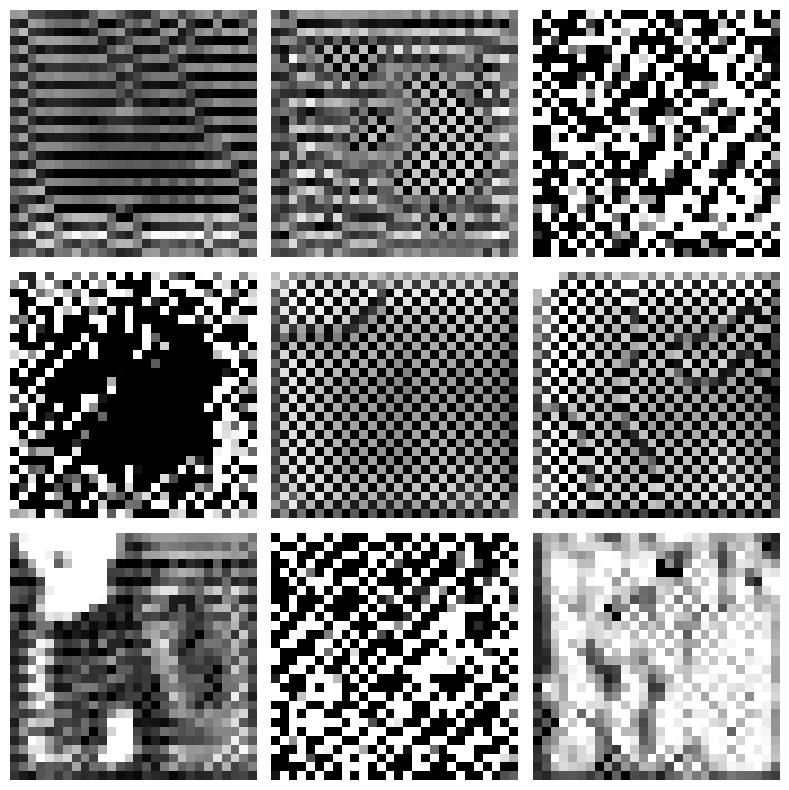


Generating samples with morphometric conditioning...
Generating 4 samples using EMA model...
Using 100 integration steps for high quality...
Visualizing samples...


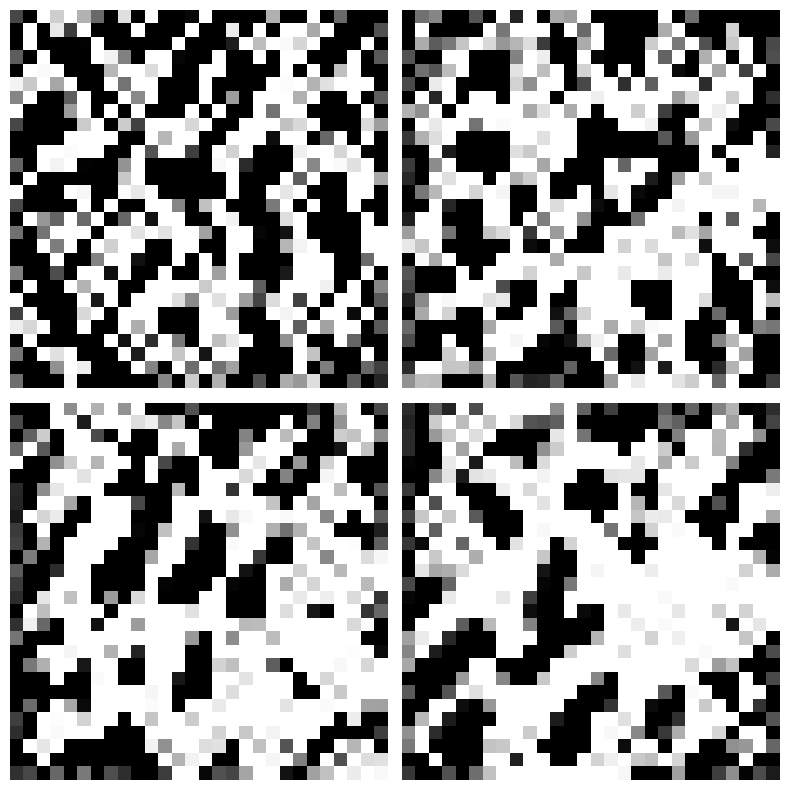

Sample generation completed!


In [15]:
import numpy as np
import matplotlib.pyplot as plt

def sample(model, rf, num_samples, cfg_scale, y=None, morpho=None, num_steps=50, device='cuda'):
    """Generate samples using the trained flow matching model

    Args:
        model: Trained MiniUnet model
        rf: RectifiedFlow instance
        num_samples: Number of samples to generate
        cfg_scale: Classifier-free guidance scale
        y: Labels for conditioning (optional)
        morpho: Morphometric features for conditioning (optional)
        num_steps: Number of integration steps
        device: Device to run on
    """
    if y is not None:
        assert len(y.shape) == 1, 'y must be 1D tensor'
        if y.shape[0] == 1:
            y = y.repeat(num_samples, 1).reshape(num_samples)
        y = y.to(device)

    # Handle morphometric conditioning
    if morpho is not None:
        for k, v in morpho.items():
            if v.shape[0] == 1:
                morpho[k] = v.repeat(num_samples)
            morpho[k] = morpho[k].to(device)

    model.eval()
    with torch.no_grad():
        dt = 1.0 / num_steps  # Use num_steps for better integration
        # Start from noise
        x_t = torch.randn(num_samples, 1, 28, 28, device=device)

        # Integrate the flow from t=0 to t=1
        for i in range(num_steps):
            t = torch.full((num_samples,), i * dt, device=device)

            # Unconditional prediction
            v_pred_uncon = model(x_t, t)

            # Conditional prediction
            v_pred_con = model(x_t, t, y, morpho)

            # Classifier-free guidance
            v_pred = v_pred_uncon + cfg_scale * (v_pred_con - v_pred_uncon)
            x_t = rf.euler(x_t, v_pred, dt)

        return x_t

def visualize_samples(samples, num_display=16, figsize=(8, 8)):
    """Visualize generated samples

    Args:
        samples: Generated samples tensor [B, 1, 28, 28]
        num_display: Number of samples to display
        figsize: Figure size
    """
    # Move to CPU and convert to numpy
    samples = samples.cpu().numpy()

    # Clamp values to [0, 1] range
    samples = np.clip(samples, 0, 1)

    # Calculate grid dimensions
    grid_size = int(np.sqrt(num_display))
    if grid_size * grid_size < num_display:
        grid_size += 1

    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten() if num_display > 1 else [axes]

    for i in range(num_display):
        if i < len(samples):
            # Remove channel dimension and display
            img = samples[i, 0]  # Shape: [28, 28]
            axes[i].imshow(img, cmap='gray')
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

def generate_samples_with_ema(ema_model, rf, cfg_scale, y=None, morpho=None, num_samples=16, num_steps=100, device='cuda'):
    """Generate samples using the EMA model directly

    Args:
        ema_model: The EMA model (ema.module)
        rf: RectifiedFlow instance
        cfg_scale: Classifier-free guidance scale
        y: Labels for conditioning (optional)
        morpho: Morphometric features for conditioning (optional)
        num_samples: Number of samples to generate
        num_steps: Number of integration steps for better quality
    """
    print(f"Generating {num_samples} samples using EMA model...")
    print(f"Using {num_steps} integration steps for high quality...")

    # Generate samples using the EMA model
    samples = sample(ema_model, rf, num_samples=num_samples, cfg_scale=cfg_scale, y=y, morpho=morpho, num_steps=num_steps, device=device)

    print("Visualizing samples...")
    visualize_samples(samples, num_samples)

    return samples

# Use the EMA model for sampling (no need to load checkpoint)
sampling_model = ema.module
sampling_model.eval()

# Example 1: Generate samples with label conditioning only
print("Generating samples with label conditioning only...")
samples = generate_samples_with_ema(sampling_model, rf, y=torch.arange(1,10,1), cfg_scale=7, num_samples=9, num_steps=100, device='cuda')

# Example 2: Generate samples with morphometric conditioning
print("\nGenerating samples with morphometric conditioning...")
morpho_condition = {
    'area': torch.tensor([100.0, 150.0, 200.0, 250.0]),  # Different area values
    'thickness': torch.tensor([1.2, 1.5, 1.8, 2.0]),    # Different thickness values
    'length': torch.tensor([8.0, 9.0, 10.0, 11.0])      # Different length values
}

samples_morpho = generate_samples_with_ema(
    sampling_model, rf,
    y=torch.tensor([7, 7, 7, 7]),  # All digit "7" but with different morphometrics
    morpho=morpho_condition,
    cfg_scale=7,
    num_samples=4,
    num_steps=100,
    device='cuda'
)

print("Sample generation completed!")